In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns   
import numpy as np



In [6]:
df=pd.read_csv("Churn_Modelling.csv")

In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


1=means exited
2=still has the card

In [8]:
df.shape

(10000, 14)

In [9]:
df.info()
#the dataset is clean as it had no null values and even the datatypes are correct

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [10]:
#check for the duplicate row
df.duplicated().sum()#NO repeated rows

np.int64(0)

In [11]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [12]:
df['Exited'].value_counts()#value counts tell the freq of each class
#Data is imbalanced as the number of people who exited is less than the people who did not exit


Exited
0    7963
1    2037
Name: count, dtype: int64

In [13]:
df['Geography'].value_counts()

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

In [14]:
df['Gender'].value_counts()

Gender
Male      5457
Female    4543
Name: count, dtype: int64

In [15]:
df.drop(['RowNumber','CustomerId','Surname'],axis=1,inplace=True)

In [16]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [32]:
df=pd.get_dummies(df,columns=['Geography','Gender'],drop_first=True,dtype=int)# basically we convert the categorial data into numerical data in such a way that we get 0 and 1 for each

whenever working with neural nets it is recommened to scale the values


In [33]:
X=df.drop(['Exited'],axis=1)
y=df['Exited']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [34]:
print(X_train.shape)
print(y_test.shape)

(8000, 11)
(2000,)


In [35]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()

In [36]:
X_train

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
7389,667,34,5,0.00,2,1,0,163830.64,0,1,0
9275,427,42,1,75681.52,1,1,1,57098.00,1,0,1
2995,535,29,2,112367.34,1,1,0,185630.76,0,0,0
5316,654,40,5,105683.63,1,1,0,173617.09,0,1,1
356,850,57,8,126776.30,2,1,1,132298.49,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...
9225,594,32,4,120074.97,2,1,1,162961.79,1,0,0
4859,794,22,4,114440.24,1,1,1,107753.07,0,1,0
3264,738,35,5,161274.05,2,1,0,181429.87,0,0,1
9845,590,38,9,0.00,2,1,1,148750.16,0,1,0


In [37]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 8000 entries, 7389 to 2732
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CreditScore        8000 non-null   int64  
 1   Age                8000 non-null   int64  
 2   Tenure             8000 non-null   int64  
 3   Balance            8000 non-null   float64
 4   NumOfProducts      8000 non-null   int64  
 5   HasCrCard          8000 non-null   int64  
 6   IsActiveMember     8000 non-null   int64  
 7   EstimatedSalary    8000 non-null   float64
 8   Geography_Germany  8000 non-null   int64  
 9   Geography_Spain    8000 non-null   int64  
 10  Gender_Male        8000 non-null   int64  
dtypes: float64(2), int64(9)
memory usage: 750.0 KB


In [39]:
# we need to scale the data as the range of data is very large and it will affect the performance of the model
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)# note it reutns a numpy array

In [43]:
import tensorflow 
from tensorflow import keras
from tensorflow.keras import Sequential# it has linear stack of layers 
from tensorflow.keras.layers import Dense# dense if a fully connected neural network layer


In [45]:
model=Sequential()# first we create an object of the sequential class
model.add(Dense(6,activation='sigmoid',input_dim=11))# we add the first layer with 6 perceptrons and sigmoid activation function and input dim is 11 as we have 11 features(this is the input layer)
model.add(Dense(1,activation='sigmoid'))# this is out output layer as we have to predict whether the customer will exit or not so we have only 1 output and sigmoid activation function is used as it is a binary classification problem


/Users/ryankhurana/Desktop/Deeplearning/venv/lib/python3.13/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 6)              │            72 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79 (316.00 B)

 Trainable params: 79 (316.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
# our problem is a binary classification problem so we will use binary_crossentropy as our loss function and adam optimizer and we will also use accuracy as our metric to evaluate the model
model.compile(loss='binary_crossentropy',optimizer='adam')

In [63]:
history=model.fit(X_train_scaled,y_train,epochs=100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - loss: 0.3531 
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 249us/step - loss: 0.3527
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 231us/step - loss: 0.3523
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 229us/step - loss: 0.3521
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 236us/step - loss: 0.3517
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 229us/step - loss: 0.3514
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 230us/step - loss: 0.3510
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 245us/step - loss: 0.3507
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 234us/step - loss: 0.3504
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 232us/step - loss: 0.3500
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 286us/step - loss: 0.3497
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 251us/step - loss: 0.3492
Epoch 13/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 239us/step - loss: 0.3489
Epoch 14/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 253us/step - loss: 0.3485
Epoch 15/100
2

In [53]:
model.layers[0].get_weights()# it will give us the weights and bias of the first layer

[array([[ 0.16200367,  0.0112023 ,  0.24904267,  0.12727225, -0.02110499,
          0.2656816 ],
        [-3.131276  , -0.9245708 , -0.0861879 ,  0.2815664 , -2.5297558 ,
         -1.847529  ],
        [ 0.56075555, -0.1137485 ,  0.1392721 ,  0.12803444, -0.07561991,
         -0.15546574],
        [ 0.34264356, -0.7900993 ,  0.0430962 , -0.79839075, -0.41885728,
          0.2968558 ],
        [-0.7045155 , -4.455441  ,  1.2349563 , -0.67444044, -0.7559058 ,
         -0.64835054],
        [ 0.24738343, -0.05437292,  0.01288396, -0.01398584,  0.0534572 ,
         -0.17462443],
        [-1.0723228 , -0.8656095 , -1.0155336 ,  0.72528005, -0.40178967,
         -0.5570897 ],
        [ 0.15001237,  0.05284148, -0.20385183, -0.3086954 , -0.01804416,
          0.07377703],
        [ 0.35597914,  0.38576612,  0.078129  , -0.51512194, -0.3872589 ,
         -0.10590013],
        [ 0.2003915 , -0.27131632,  0.42616928,  0.08271594,  0.4155464 ,
         -0.47465765],
        [-0.39322641,  0.13827

In [54]:
model.layers[1].get_weights()

[array([[-1.5875235],
        [ 3.6991866],
        [ 2.5881593],
        [-2.3475306],
        [-1.2000521],
        [-1.8947334]], dtype=float32),
 array([-0.3249539], dtype=float32)]

In [56]:
y_log=model.predict(X_test_scaled)# as we use sigmoiid as a activation function in the output layer so it basially return the probability of the customer exiting the bank and if the probability is greater than 0.5 then we can say that the customer will exit otherwise not


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step


In [59]:
convert_to_prob=np.where(y_log>0.5,1,0)# if the probability is greater than 0.5 then we can say that the customer will exit otherwise not

In [60]:
from sklearn.metrics import accuracy_score
accuracy_score_model=accuracy_score(y_test,convert_to_prob)

In [61]:
print(accuracy_score_model)

0.864


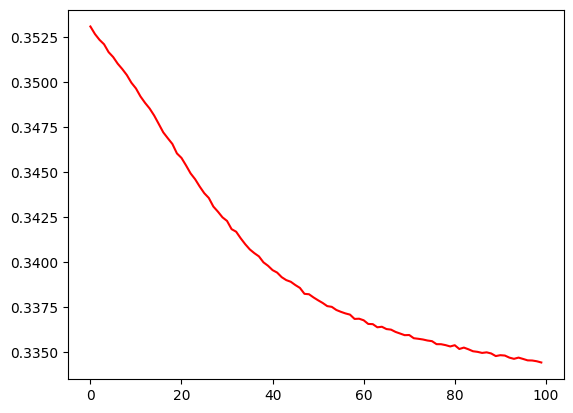

In [67]:
history.history
plt.plot(history.history['loss'],label='loss',color='red')

In [69]:
plt.plot(history.history['accuracy'],label='accuracy',color='blue')

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 279us/step - accuracy: 0.8641 - loss: 0.3345
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8633 - loss: 0.3344
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8637 - loss: 0.3343
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 262us/step - accuracy: 0.8636 - loss: 0.3341
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 264us/step - accuracy: 0.8639 - loss: 0.3342
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.8636 - loss: 0.3343
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 266us/step - accuracy: 0.8639 - loss: 0.3342
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.8634 - loss: 0.3340
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step - accuracy: 0.8633 - loss: 0.3341
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.8631 - loss: 0.3342
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 267us/step - accuracy: 0.8639 - loss: 0.3339
Epoch 12/100
250/25

In [71]:
history.history.keys()# it will give us the keys of the history dictionary which contains the loss and accuracy values for each epoch

dict_keys(['accuracy', 'loss'])